In [23]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

plt.style.use('dark_background')

cyber_palette = ['#ff00ff','#00ffff','#39ff14','#ff1493','#9400d3']
sns.set_palette(cyber_palette)

plt.rcParams['figure.figsize']=(8,5)
plt.rcParams['axes.facecolor']='#0d0d0d'
plt.rcParams['grid.color']='#444444'
plt.rcParams['axes.edgecolor']='#ffffff'

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw")


ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = ROOT / "data" / "raw"
DATA_ext = ROOT / "data" / "external"
print(f"Project root: {ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Data ext: {DATA_ext}")

Project root: C:\Users\gshar\anime-recommendation
Data dir: C:\Users\gshar\anime-recommendation\data\raw
Data ext: C:\Users\gshar\anime-recommendation\data\external


In [24]:
# data load
anime  = pd.read_csv(DATA_ext / "anime.csv")
rating = pd.read_csv(DATA_ext / "rating.csv")
fandom = pd.read_csv(DATA_DIR / "fandom.csv")


In [25]:
def quality_report(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    report = pd.DataFrame(
        {
            "dtype": frame.dtypes.astype(str),
            "nulls": frame.isna().sum(),
            "null_pct": (frame.isna().mean() * 100).round(2),
            "nunique": frame.nunique(dropna=False),
        }
    ).sort_values(["null_pct", "nunique"], ascending=[False, True]).style.background_gradient(cmap='cool')
    print(f"{name} shape: {frame.shape}")
    print(f"{name} duplicate rows: {frame.duplicated().sum()}")
    print(f"{name} mathematical view:\n ")
    display(frame.describe().T.style.background_gradient(cmap='cool'))
    print('--'*50)
    print('DATA INFO')
    print('--'*50)
    return report


display(quality_report(anime, "anime"))
display(quality_report(rating, "rating"))
display(quality_report(fandom, "fandom"))

print("duplicate anime_ids:", anime["anime_id"].duplicated().sum())
print("duplicate user_ids:", rating["user_id"].duplicated().sum())
print("duplicate page_ids:", fandom["pageid"].duplicated().sum())


anime shape: (12294, 7)
anime duplicate rows: 0
anime mathematical view:
 


,count,mean,std,min,25%,50%,75%,max
anime_id,12294.000000,14058.221653,11455.294701,1.000000,3484.250000,10260.500000,24794.500000,34527.000000
rating,12064.000000,6.473902,1.026746,1.670000,5.880000,6.570000,7.180000,10.000000
members,12294.000000,18071.338864,54820.676925,5.000000,225.000000,1550.000000,9437.000000,1013917.000000


----------------------------------------------------------------------------------------------------
DATA INFO
----------------------------------------------------------------------------------------------------


,dtype,nulls,null_pct,nunique
rating,float64,230,1.870000,599
genre,str,62,0.500000,3265
type,str,25,0.200000,7
episodes,str,0,0.000000,187
members,int64,0,0.000000,6706
name,str,0,0.000000,12292
anime_id,int64,0,0.000000,12294


rating shape: (7813737, 3)
rating duplicate rows: 1
rating mathematical view:
 


...

fandom shape: (10014, 3)
fandom duplicate rows: 0
fandom mathematical view:
 


,count,mean,std,min,25%,50%,75%,max
pageid,10014.000000,19577.639704,8760.857005,1461.000000,12464.250000,20243.000000,27982.750000,31691.000000


----------------------------------------------------------------------------------------------------
DATA INFO
----------------------------------------------------------------------------------------------------


,dtype,nulls,null_pct,nunique
description,str,0,0.000000,8505
pageid,int64,0,0.000000,10014
title,str,0,0.000000,10014


duplicate anime_ids: 0
duplicate user_ids: 7740222
duplicate page_ids: 0


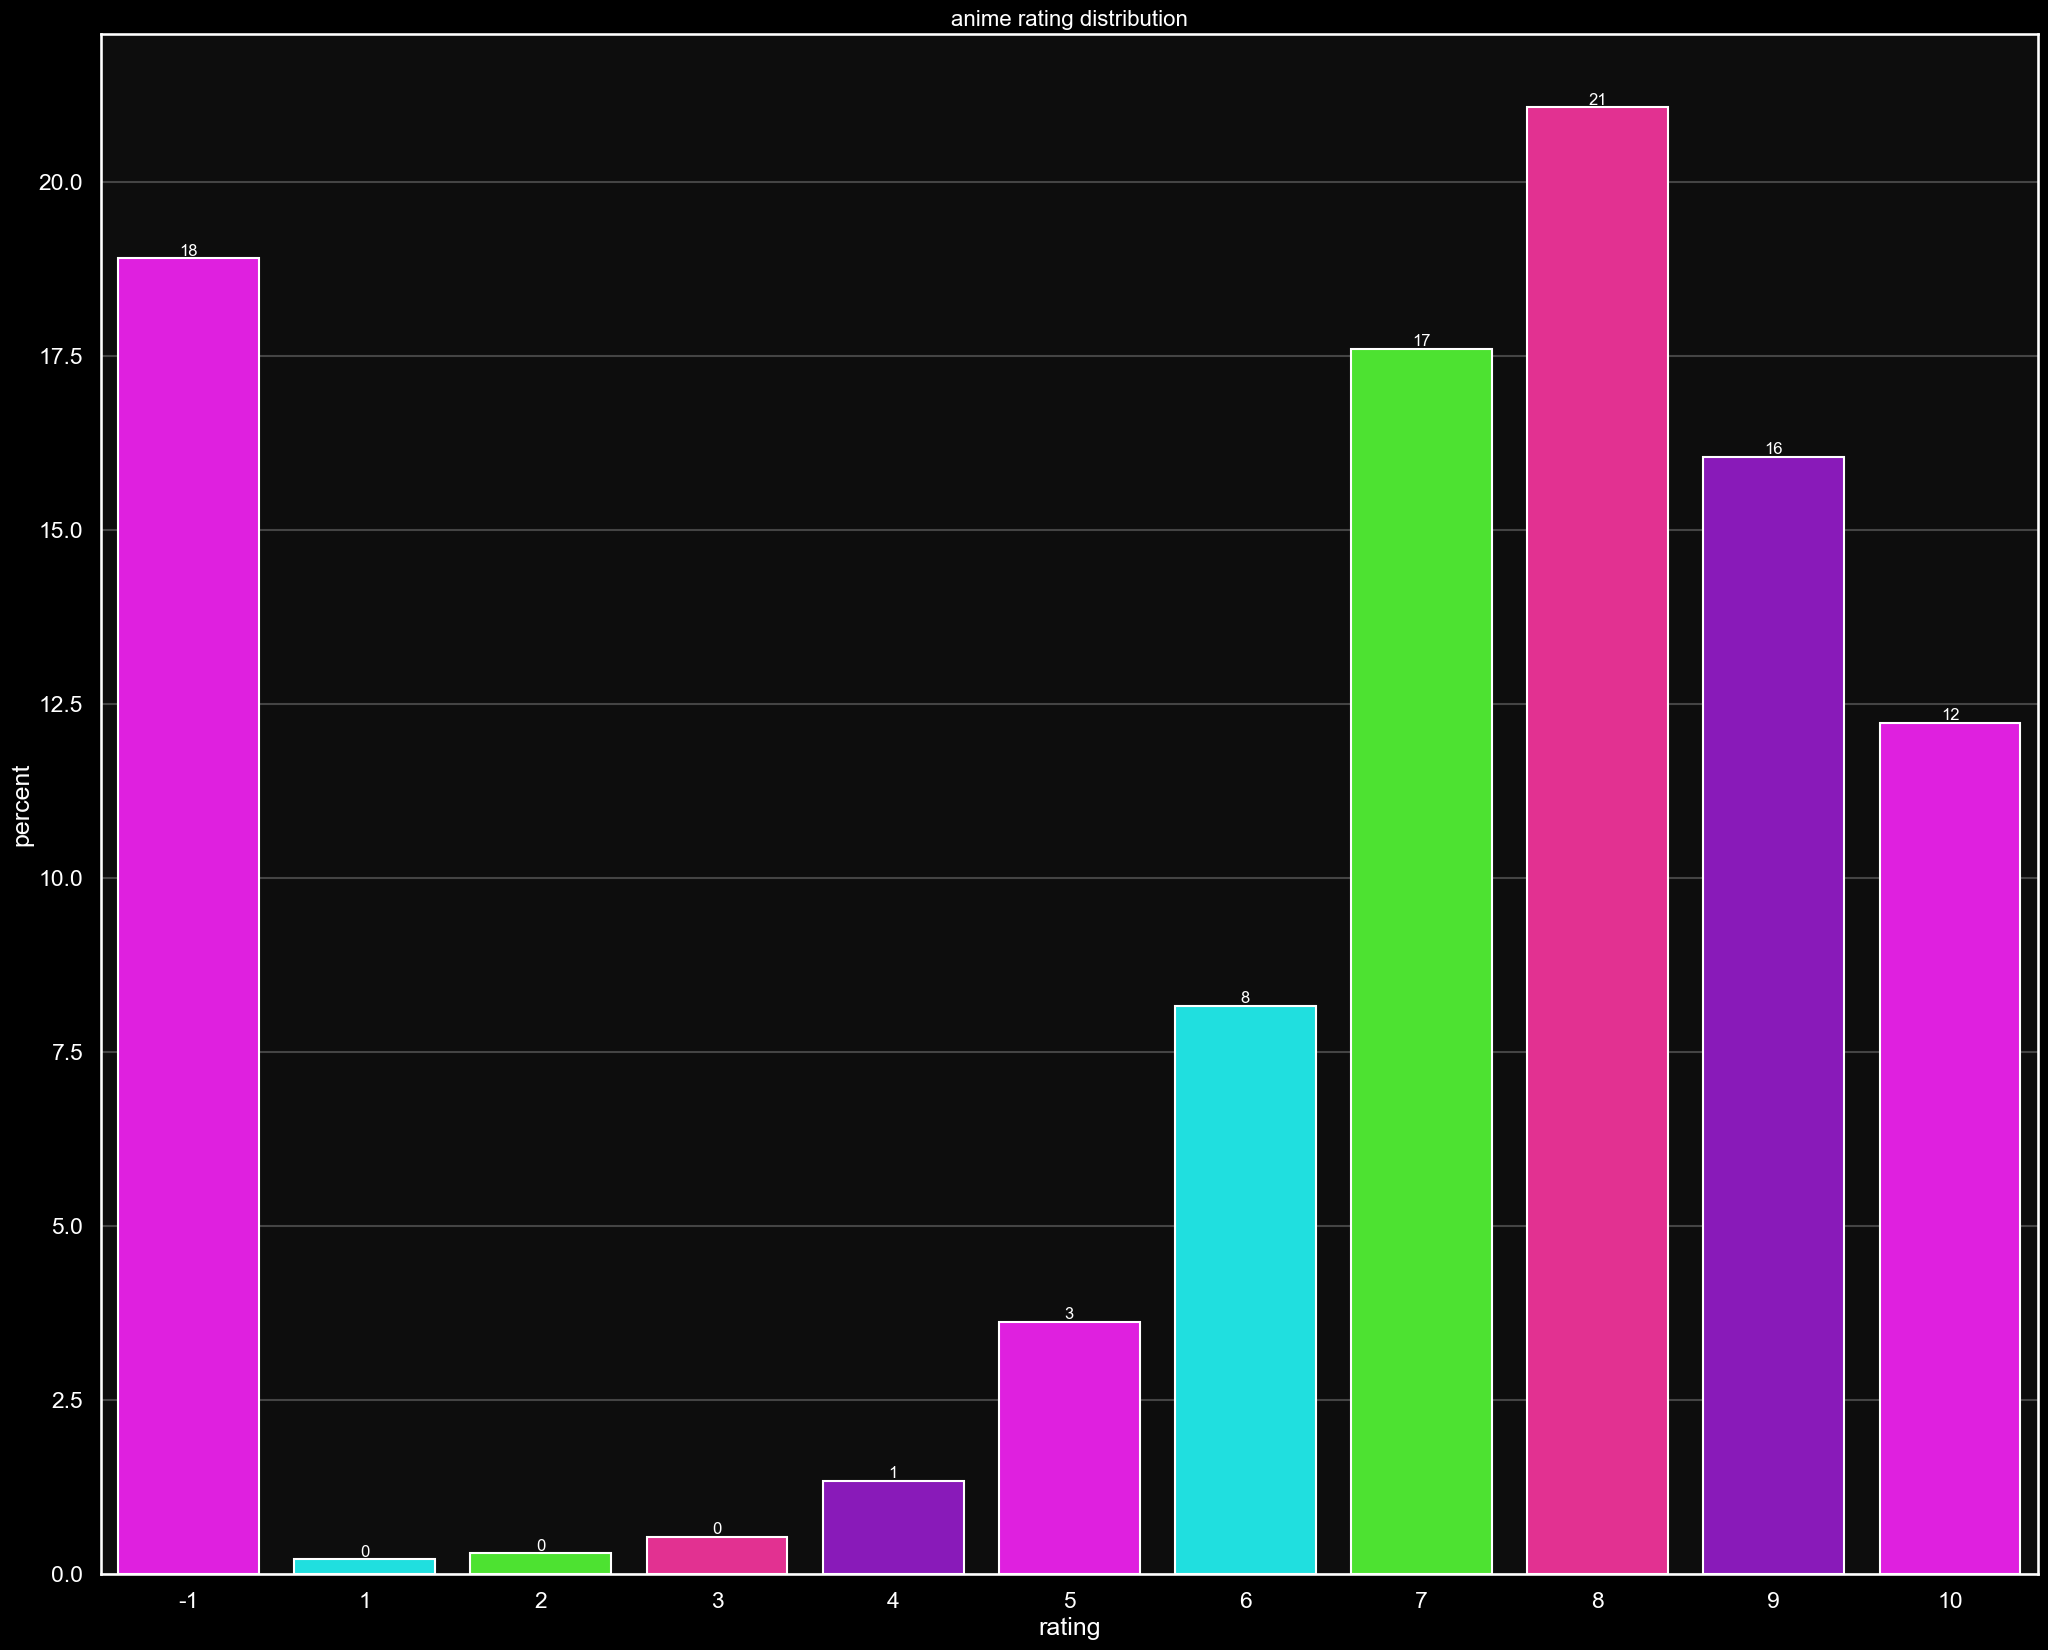

In [26]:

plt.figure(figsize=(25,20))

ax = sns.countplot(
    x='rating',
    data=rating,
    palette=cyber_palette,
    stat='percent'
)

# Add value counts on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',   # value count
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.title('anime rating distribution', fontsize=16)
plt.show()

In [27]:
rating.groupby('user_id').size().describe() 

count    73515.000000
mean       106.287656
std        153.086558
min          1.000000
25%         18.000000
50%         57.000000
75%        136.000000
max      10227.000000
dtype: float64

In [28]:
anime['genre'].value_counts().head(3)

genre
Hentai    823
Comedy    523
Music     301
Name: count, dtype: int64

In [29]:
print("Empty descriptions:", fandom['description'].eq('').sum())
print("Avg description length:", fandom['description'].str.len().mean())

Empty descriptions: 0
Avg description length: 328.3015777910925


<Axes: >

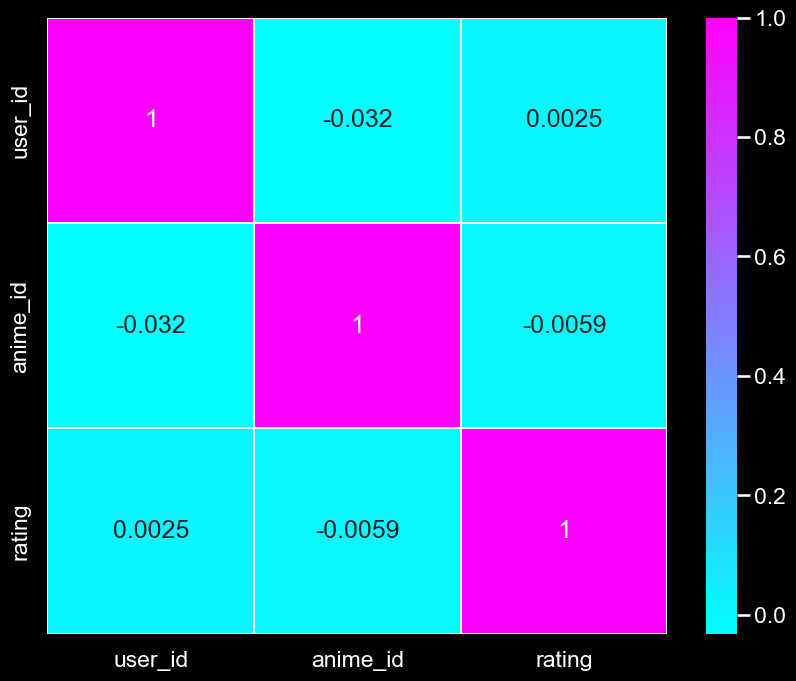

In [30]:
plt.figure(figsize=(10,8))
corr = rating.corr(numeric_only=True)

sns.heatmap(corr,annot = True,cmap='cool',linewidths=0.3)

<Axes: >

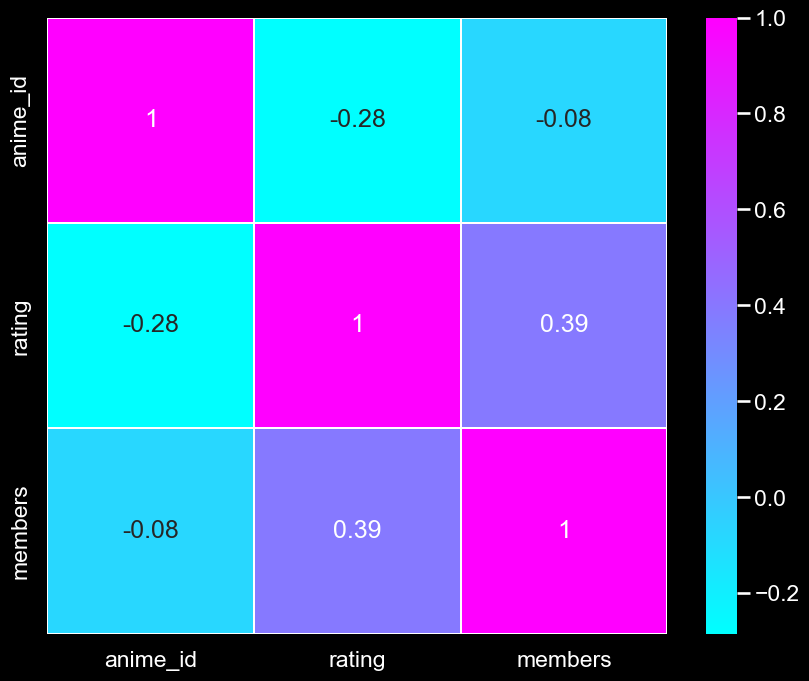

In [31]:
plt.figure(figsize=(10,8))
corr = anime.corr(numeric_only=True)

sns.heatmap(corr,annot = True,cmap='cool',linewidths=0.3)

Text(0.5, 1.0, 'anime ratings')

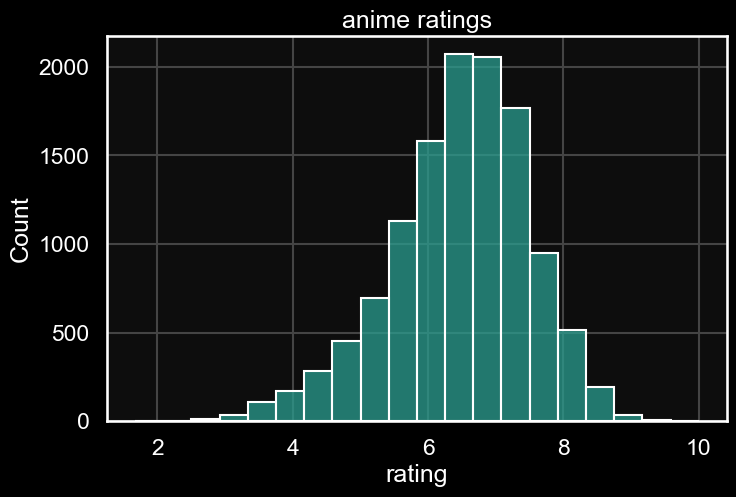

In [32]:
sns.histplot(anime["rating"], bins=20,  color="#2a9d8f")
plt.title("anime ratings")

In [33]:
import pandas as pd
train = pd.read_parquet("../data/processed/rating_train.parquet")

# check user 1
user1_ratings = train[train['user_id'] == 1]
print(f"User 1 has {len(user1_ratings)} ratings")

# find most active user
top_user = train.groupby('user_id').size().idxmax()
print(f"\nMost active user: {top_user}")
print(f"Their ratings: {train[train['user_id']==top_user].shape[0]}")

User 1 has 3 ratings

Most active user: 42635
Their ratings: 2617


In [ ]:
import joblib
import numpy as np

# Load model and indices
model     = joblib.load("../models/als_model.pkl")
user_idx  = joblib.load("../models/user_idx.pkl")
anime_idx = joblib.load("../models/anime_idx.pkl")
matrix    = joblib.load("../data/features/user_item_matrix.pkl")

# Access factors from the model object
user_factors = model.user_factors
item_factors = model.item_factors

# get recommendations for active user
u      = user_idx[42635]
scores = (user_factors[u] @ item_factors.T).copy()

# get top 5 scores
top_indices = np.argsort(scores)[::-1][:5]
idx_to_anime = {v: k for k, v in anime_idx.items()}

print("Top 5 recommendations for user 42635:")
for rank, idx in enumerate(top_indices, 1):
    print(f"  Rank {rank}: anime_id={idx_to_anime[idx]} score={scores[idx]:.4f}")

Top 5 recommendations for user 42635:


KeyError: np.int64(6310)

In [ ]:
import pandas as pd
anime = pd.read_parquet("../data/processed/anime.parquet")

# check if recommended anime_ids exist
rec_ids = [13955, 3686, 31865]
print(anime[anime['anime_id'].isin(rec_ids)][['anime_id', 'name', 'genre']])

      anime_id                                    name  \
3889      3686    tokimeki memorial only love specials   
4769     13955                      dennou coil recaps   
5343     31865  kare baka wagahai no kare wa baka de r   

                                          genre  
3889                             Comedy, School  
4769  Adventure, Comedy, Drama, Mystery, Sci-Fi  
5343                    Comedy, Romance, School  


In [ ]:
model = joblib.load("../models/als_model.pkl")
print("item_factors:", model.item_factors.shape)  # should be (5813, 50)
print("user_factors:", model.user_factors.shape)  # should be (69524, 50)

item_factors: (69524, 50)
user_factors: (5813, 50)


In [ ]:
import joblib
import numpy as np

model     = joblib.load("../models/als_model.pkl")
user_idx  = joblib.load("../models/user_idx.pkl")
anime_idx = joblib.load("../models/anime_idx.pkl")
matrix    = joblib.load("../data/features/user_item_matrix.pkl")
anime     = pd.read_parquet("../data/processed/anime.parquet")

idx_to_anime = {v: k for k, v in anime_idx.items()}

# test active user
u = user_idx[42635]
anime_ids, scores = model.recommend(u, matrix[u], N=10)

print("Raw indices:", anime_ids[:5])
print("Scores:", scores[:5])

rec_ids = [idx_to_anime.get(int(idx)) for idx in anime_ids]
print(anime[anime['anime_id'].isin(rec_ids)][['name', 'genre', 'rating']])

IndexError: index 40236 is out of bounds for axis 0 with size 5813